In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root(start: Path) -> Path:
    """
    Locate the repository root by searching upward for processed outputs.
    """
    for candidate in [start, *start.parents]:
        processed_dir = candidate / "data" / "processed"
        reports_dir = candidate / "reports" / "tables"

        if processed_dir.exists() and reports_dir.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Expected data/processed and reports/tables directories."
    )


PROJECT_ROOT = _find_project_root(Path.cwd())

US_IV_PATH = PROJECT_ROOT / "data" / "processed" / "us_iv.parquet"
INDIA_IV_PATH = PROJECT_ROOT / "data" / "processed" / "india_iv.parquet"

US_VRP_PATH = PROJECT_ROOT / "data" / "processed" / "us_vrp.parquet"
INDIA_VRP_PATH = PROJECT_ROOT / "data" / "processed" / "india_vrp.parquet"

VRP_SUMMARY_PATH = PROJECT_ROOT / "reports" / "tables" / "vrp_summary.csv"
VRP_METADATA_PATH = PROJECT_ROOT / "reports" / "tables" / "vrp_metadata.json"
CALENDAR_MISMATCH_PATH = PROJECT_ROOT / "reports" / "tables" / "calendar_mismatches.csv"

required_paths = {
    "US_IV_PATH": US_IV_PATH,
    "INDIA_IV_PATH": INDIA_IV_PATH,
    "US_VRP_PATH": US_VRP_PATH,
    "INDIA_VRP_PATH": INDIA_VRP_PATH,
    "VRP_SUMMARY_PATH": VRP_SUMMARY_PATH,
    "VRP_METADATA_PATH": VRP_METADATA_PATH,
    "CALENDAR_MISMATCH_PATH": CALENDAR_MISMATCH_PATH,
}

missing_paths = [name for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    print(f"Project root: {PROJECT_ROOT}")
    print("Missing required notebook inputs:")
    for name in missing_paths:
        print(f"  - {name}: {required_paths[name]}")
    raise FileNotFoundError(
        "One or more processed outputs or reports are missing. Run the feature build pipeline first."
    )

us_iv = pd.read_parquet(US_IV_PATH)
india_iv = pd.read_parquet(INDIA_IV_PATH)

us_vrp = pd.read_parquet(US_VRP_PATH)
india_vrp = pd.read_parquet(INDIA_VRP_PATH)

for df in [us_iv, india_iv, us_vrp, india_vrp]:
    df["date"] = pd.to_datetime(df["date"])

print("US IV:", us_iv.shape)
print("India IV:", india_iv.shape)
print("US VRP:", us_vrp.shape)
print("India VRP:", india_vrp.shape)

display(us_vrp.head())
display(india_vrp.head())


US IV: (9186, 5)
India IV: (4220, 5)
US VRP: (9156, 32)
India VRP: (4204, 32)


,date,market,underlying_symbol,iv_symbol,iv_close,iv_ann,rv_gk_daily,rv_gk_22d_ann,rv_gk_22d_ann_lag1,vrp_backward_gk,...,vrp_backward_cc_positive,rv_parkinson_22d_ann_lag1,vrp_backward_parkinson,vrp_backward_parkinson_positive,rv_rs_22d_ann_lag1,vrp_backward_rs,vrp_backward_rs_positive,rv_yz_22d_ann_lag1,vrp_backward_yz,vrp_backward_yz_positive
0,1990-01-02,US,US_UNDERLYING,VIX,17.24,0.029722,0.000115,NaN,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1,1990-01-03,US,US_UNDERLYING,VIX,18.19,0.033088,0.000026,NaN,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
2,1990-01-04,US,US_UNDERLYING,VIX,19.22,0.036941,0.000107,NaN,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
3,1990-01-05,US,US_UNDERLYING,VIX,20.11,0.040441,0.000038,NaN,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
4,1990-01-08,US,US_UNDERLYING,VIX,20.26,0.041047,0.000047,NaN,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>


,date,market,underlying_symbol,iv_symbol,iv_close,iv_ann,rv_gk_daily,rv_gk_22d_ann,rv_gk_22d_ann_lag1,vrp_backward_gk,...,vrp_backward_cc_positive,rv_parkinson_22d_ann_lag1,vrp_backward_parkinson,vrp_backward_parkinson_positive,rv_rs_22d_ann_lag1,vrp_backward_rs,vrp_backward_rs_positive,rv_yz_22d_ann_lag1,vrp_backward_yz,vrp_backward_yz_positive
0,2009-03-02,INDIA,INDIA_UNDERLYING,INDIA_VIX,43.360001,0.188009,0.000327,0.066236,NaN,NaN,...,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1,2009-03-03,INDIA,INDIA_UNDERLYING,INDIA_VIX,44.439999,0.197491,0.000285,0.065464,0.066236,0.131256,...,True,0.071731,0.125760,True,0.067077,0.130415,True,0.070538,0.126954,True
2,2009-03-04,INDIA,INDIA_UNDERLYING,INDIA_VIX,42.770000,0.182927,0.000076,0.059552,0.065464,0.117463,...,True,0.072046,0.110881,True,0.065957,0.116971,True,0.069940,0.112988,True
3,2009-03-05,INDIA,INDIA_UNDERLYING,INDIA_VIX,41.560001,0.172723,0.000458,0.061838,0.059552,0.113171,...,True,0.067280,0.105444,True,0.058929,0.113794,True,0.063743,0.108981,True
4,2009-03-06,INDIA,INDIA_UNDERLYING,INDIA_VIX,37.970001,0.144172,0.000481,0.062847,0.061838,0.082334,...,True,0.066683,0.077489,True,0.062133,0.082039,True,0.065440,0.078733,True


In [8]:
PRIMARY_COLUMNS = [
    "date",
    "market",
    "underlying_symbol",
    "iv_symbol",
    "iv_close",
    "iv_ann",
    "rv_gk_daily",
    "rv_gk_22d_ann",
    "rv_gk_22d_ann_lag1",
    "vrp_backward_gk",
    "vrp_backward_gk_positive",
    "rv_gk_22d_forward_ann_label",
    "vrp_forward_expost_gk_label",
    "feature_allowed",
]

ROBUSTNESS_COLUMNS = [
    "rv_cc_22d_ann_lag1",
    "vrp_backward_cc",
    "vrp_backward_cc_positive",
    "rv_parkinson_22d_ann_lag1",
    "vrp_backward_parkinson",
    "vrp_backward_parkinson_positive",
    "rv_rs_22d_ann_lag1",
    "vrp_backward_rs",
    "vrp_backward_rs_positive",
    "rv_yz_22d_ann_lag1",
    "vrp_backward_yz",
    "vrp_backward_yz_positive",
]

FORBIDDEN_COLUMNS = [
    "rv_yz_daily",
    "vrp_forward_expost_cc_label",
    "vrp_forward_expost_parkinson_label",
    "vrp_forward_expost_rs_label",
    "vrp_forward_expost_yz_label",
]

def check_vrp_panel(df: pd.DataFrame, name: str) -> None:
    missing_primary = [col for col in PRIMARY_COLUMNS if col not in df.columns]
    missing_robustness = [col for col in ROBUSTNESS_COLUMNS if col not in df.columns]
    forbidden_present = [col for col in FORBIDDEN_COLUMNS if col in df.columns]

    print(name)
    print("Missing primary:", missing_primary)
    print("Missing robustness:", missing_robustness)
    print("Forbidden present:", forbidden_present)
    print("First feature_allowed index:", df.index[df["feature_allowed"] == True].min())

    assert not missing_primary
    assert not missing_robustness
    assert not forbidden_present

check_vrp_panel(us_vrp, "US")
check_vrp_panel(india_vrp, "INDIA")

US
Missing primary: []
Missing robustness: []
Forbidden present: []
First feature_allowed index: 22
INDIA
Missing primary: []
Missing robustness: []
Forbidden present: []
First feature_allowed index: 1


In [9]:
FEATURE_COLUMNS = [
    "iv_ann",
    "rv_gk_22d_ann_lag1",
    "vrp_backward_gk",
    "vrp_backward_gk_positive",
]

LABEL_COLUMNS = [
    "rv_gk_22d_forward_ann_label",
    "vrp_forward_expost_gk_label",
]

FORBIDDEN_SUBSTRINGS = ["future", "forward", "expost", "label"]

for col in FEATURE_COLUMNS:
    for token in FORBIDDEN_SUBSTRINGS:
        assert token not in col.lower(), f"Forbidden token {token} found in feature column {col}"

for col in LABEL_COLUMNS:
    assert col not in FEATURE_COLUMNS

print("Feature/label separation OK")

Feature/label separation OK


In [10]:
AUDIT_COLUMNS = PRIMARY_COLUMNS + ROBUSTNESS_COLUMNS

def missing_audit(df: pd.DataFrame, market: str) -> pd.DataFrame:
    rows = []

    for col in AUDIT_COLUMNS:
        if col not in df.columns:
            continue

        rows.append(
            {
                "market": market,
                "column": col,
                "missing": int(df[col].isna().sum()),
                "count": int(df[col].notna().sum()),
                "first_valid_index": df[col].first_valid_index(),
            }
        )

    return pd.DataFrame(rows)

missing = pd.concat(
    [
        missing_audit(us_vrp, "US"),
        missing_audit(india_vrp, "INDIA"),
    ],
    ignore_index=True,
)

display(missing)

,market,column,missing,count,first_valid_index
0,US,date,0,9156,0
1,US,market,0,9156,0
2,US,underlying_symbol,0,9156,0
3,US,iv_symbol,0,9156,0
4,US,iv_close,0,9156,0
5,US,iv_ann,0,9156,0
6,US,rv_gk_daily,0,9156,0
7,US,rv_gk_22d_ann,21,9135,21
8,US,rv_gk_22d_ann_lag1,22,9134,22
9,US,vrp_backward_gk,22,9134,22


In [11]:
vrp_summary = pd.read_csv(VRP_SUMMARY_PATH)
calendar_mismatches = pd.read_csv(CALENDAR_MISMATCH_PATH)

display(vrp_summary)
display(calendar_mismatches)

,market,column,mean,median,std,min,max,p05,p95,count,missing,positive_count,positive_ratio
0,US,iv_ann,0.043885,0.031046,0.045812,0.008354,0.683764,0.013064,0.108785,9156,0,9156,1.000000
1,US,rv_gk_22d_ann_lag1,0.019119,0.010760,0.030285,0.001252,0.436895,0.003595,0.056400,9134,22,9134,1.000000
2,US,vrp_backward_gk,0.024738,0.018370,0.026066,-0.207373,0.567737,0.006242,0.064597,9134,22,9005,0.985877
3,US,rv_gk_22d_forward_ann_label,0.019121,0.010758,0.030286,0.001252,0.436895,0.003595,0.056400,9134,22,9134,1.000000
4,US,vrp_forward_expost_gk_label,0.024792,0.018536,0.034799,-0.303580,0.504016,0.000406,0.072498,9134,22,8685,0.950843
5,US,rv_cc_22d_ann_lag1,0.032581,0.016834,0.063985,0.001381,0.875130,0.004526,0.092913,9133,23,9133,1.000000
6,US,vrp_backward_cc,0.011275,0.011346,0.037078,-0.683848,0.322119,-0.014901,0.044089,9133,23,8042,0.880543
7,US,rv_parkinson_22d_ann_lag1,0.021521,0.012125,0.034910,0.001188,0.499993,0.003794,0.065283,9134,22,9134,1.000000
8,US,vrp_backward_parkinson,0.022337,0.016848,0.024595,-0.244773,0.550959,0.005044,0.058853,9134,22,8934,0.978104
9,US,rv_rs_22d_ann_lag1,0.018752,0.010708,0.029149,0.001206,0.433872,0.003625,0.055592,9134,22,9134,1.000000


,market,iv_start,iv_end,rv_start,rv_end,iv_rows,rv_rows,common_dates,iv_only_dates,rv_only_dates,first_iv_only_date,first_rv_only_date
0,US,1990-01-02,2026-05-14,1990-01-02,2026-05-15,9186,9160,9156,30,4,2004-06-11,1991-03-01
1,INDIA,2009-03-02,2026-05-15,2007-09-17,2026-05-15,4220,4576,4204,16,372,2011-05-31,2007-09-17


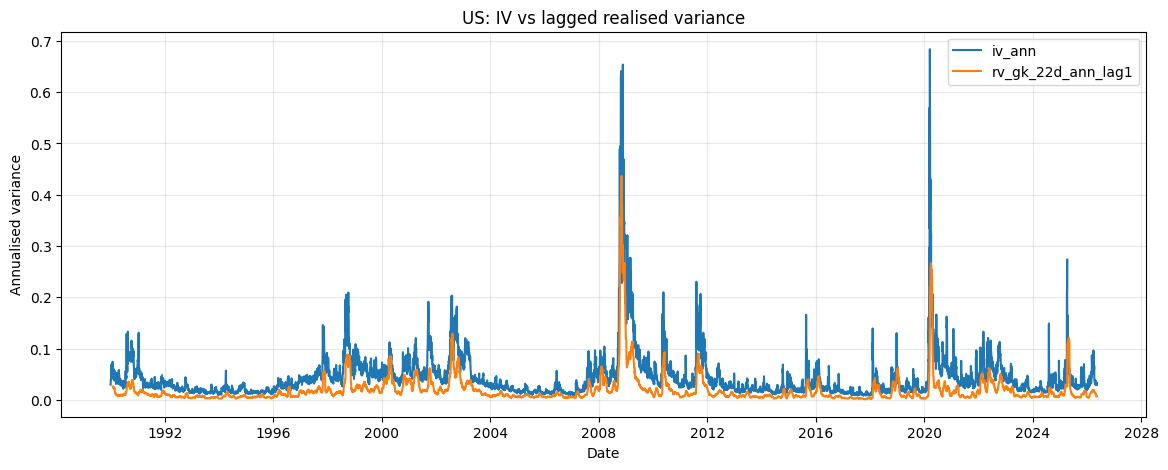

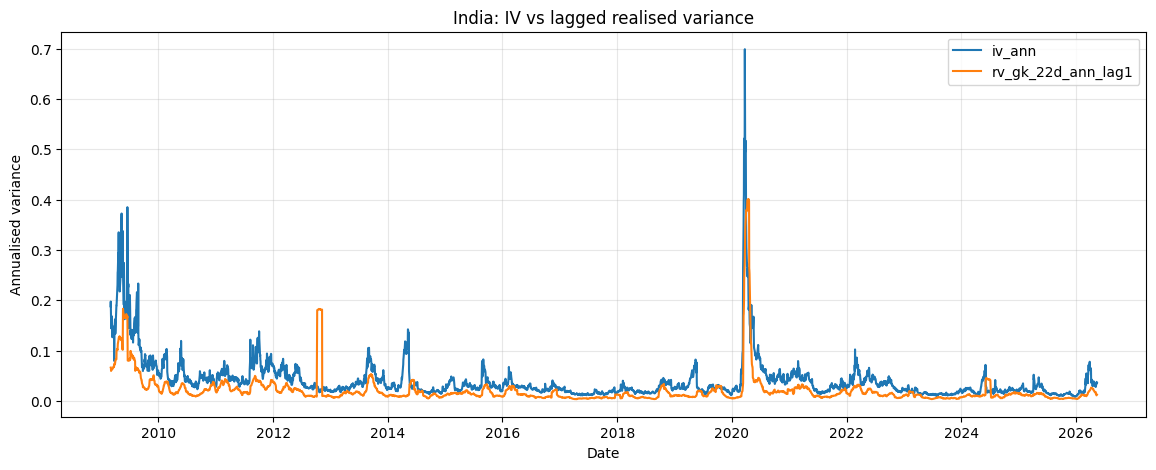

In [12]:
def plot_iv_vs_rv(df: pd.DataFrame, market: str) -> None:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(df["date"], df["iv_ann"], label="iv_ann")
    ax.plot(df["date"], df["rv_gk_22d_ann_lag1"], label="rv_gk_22d_ann_lag1")

    ax.set_title(f"{market}: IV vs lagged realised variance")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualised variance")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

plot_iv_vs_rv(us_vrp, "US")
plot_iv_vs_rv(india_vrp, "India")

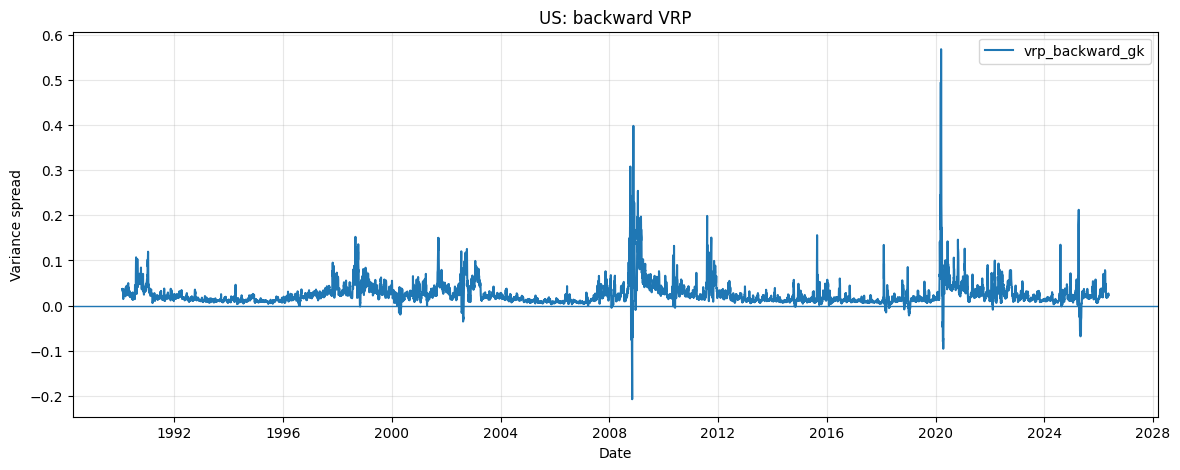

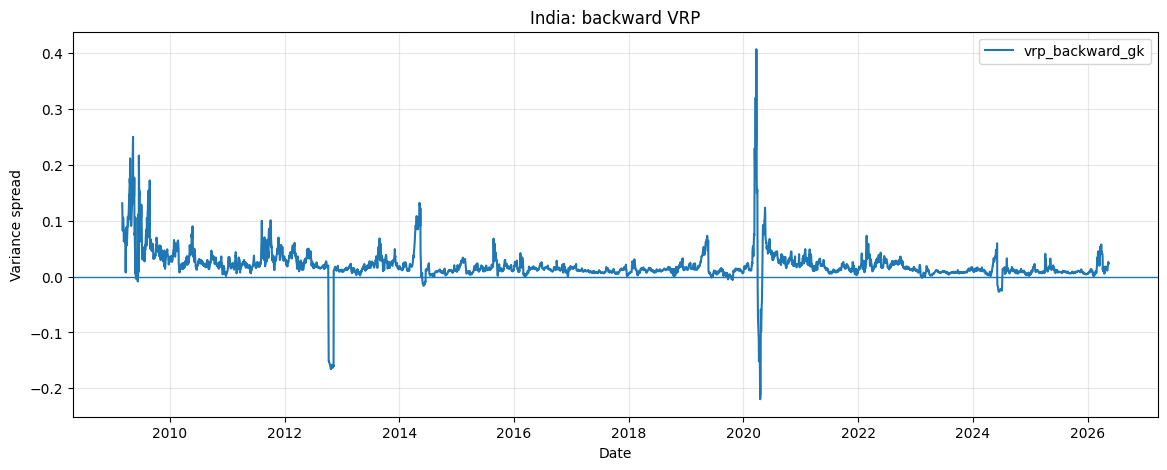

In [13]:
def plot_backward_vrp(df: pd.DataFrame, market: str) -> None:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(df["date"], df["vrp_backward_gk"], label="vrp_backward_gk")
    ax.axhline(0.0, linewidth=1)

    ax.set_title(f"{market}: backward VRP")
    ax.set_xlabel("Date")
    ax.set_ylabel("Variance spread")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

plot_backward_vrp(us_vrp, "US")
plot_backward_vrp(india_vrp, "India")

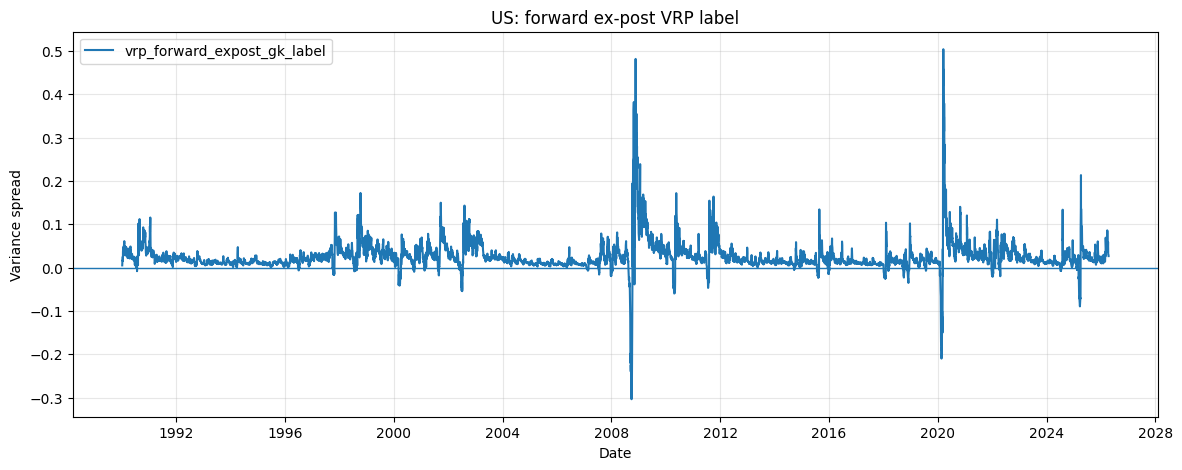

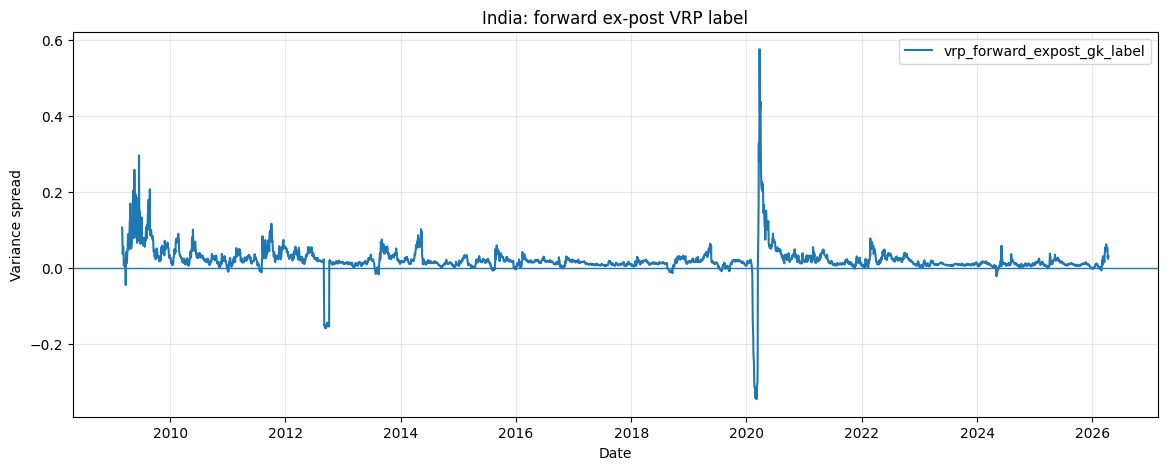

In [14]:
def plot_forward_expost_label(df: pd.DataFrame, market: str) -> None:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        df["date"],
        df["vrp_forward_expost_gk_label"],
        label="vrp_forward_expost_gk_label",
    )
    ax.axhline(0.0, linewidth=1)

    ax.set_title(f"{market}: forward ex-post VRP label")
    ax.set_xlabel("Date")
    ax.set_ylabel("Variance spread")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

plot_forward_expost_label(us_vrp, "US")
plot_forward_expost_label(india_vrp, "India")

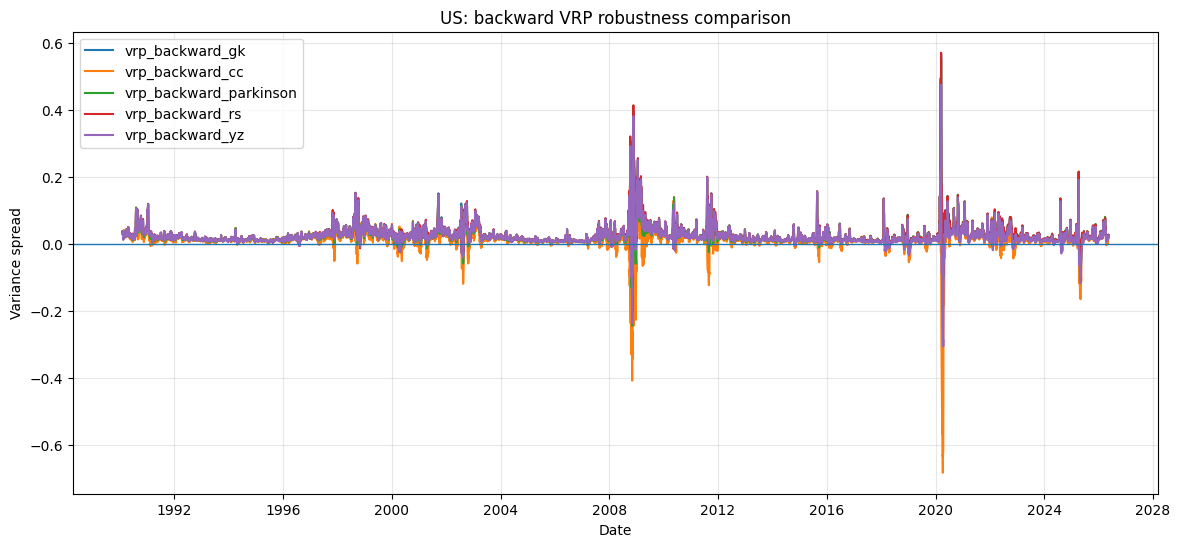

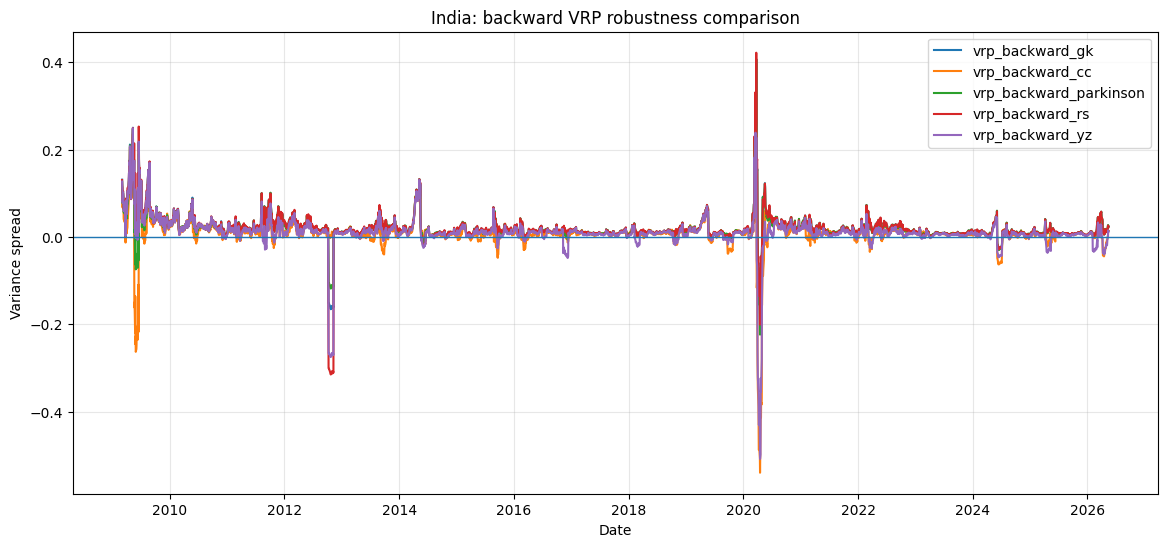

In [15]:
ROBUSTNESS_VRP_COLUMNS = [
    "vrp_backward_gk",
    "vrp_backward_cc",
    "vrp_backward_parkinson",
    "vrp_backward_rs",
    "vrp_backward_yz",
]

def plot_robustness_vrp(df: pd.DataFrame, market: str) -> None:
    fig, ax = plt.subplots(figsize=(14, 6))

    for col in ROBUSTNESS_VRP_COLUMNS:
        if col in df.columns:
            ax.plot(df["date"], df[col], label=col)

    ax.axhline(0.0, linewidth=1)
    ax.set_title(f"{market}: backward VRP robustness comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Variance spread")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

plot_robustness_vrp(us_vrp, "US")
plot_robustness_vrp(india_vrp, "India")

In [16]:
COMPARE_COLUMNS = [
    "iv_ann",
    "rv_gk_22d_ann_lag1",
    "vrp_backward_gk",
    "vrp_forward_expost_gk_label",
]

ROBUSTNESS_COMPARE_COLUMNS = [
    "vrp_backward_cc",
    "vrp_backward_parkinson",
    "vrp_backward_rs",
    "vrp_backward_yz",
]

comparison = []

for market, df in [("US", us_vrp), ("INDIA", india_vrp)]:
    for col in COMPARE_COLUMNS + ROBUSTNESS_COMPARE_COLUMNS:
        if col not in df.columns:
            continue

        values = pd.to_numeric(df[col], errors="coerce")

        comparison.append(
            {
                "market": market,
                "column": col,
                "mean": values.mean(),
                "median": values.median(),
                "std": values.std(),
                "p05": values.quantile(0.05),
                "p95": values.quantile(0.95),
                "positive_ratio": (values.dropna() > 0).mean(),
            }
        )

comparison_df = pd.DataFrame(comparison)
display(comparison_df)


,market,column,mean,median,std,p05,p95,positive_ratio
0,US,iv_ann,0.043885,0.031046,0.045812,0.013064,0.108785,1.000000
1,US,rv_gk_22d_ann_lag1,0.019119,0.010760,0.030285,0.003595,0.056400,1.000000
2,US,vrp_backward_gk,0.024738,0.018370,0.026066,0.006242,0.064597,0.985877
3,US,vrp_forward_expost_gk_label,0.024792,0.018536,0.034799,0.000406,0.072498,0.950843
4,US,vrp_backward_cc,0.011275,0.011346,0.037078,-0.014901,0.044089,0.880543
5,US,vrp_backward_parkinson,0.022337,0.016848,0.024595,0.005044,0.058853,0.978104
6,US,vrp_backward_rs,0.025105,0.018527,0.026757,0.006151,0.065557,0.982374
7,US,vrp_backward_yz,0.021564,0.016537,0.026430,0.003807,0.059409,0.967809
8,INDIA,iv_ann,0.040477,0.028107,0.044404,0.012928,0.102381,1.000000
9,INDIA,rv_gk_22d_ann_lag1,0.020829,0.012750,0.032908,0.004989,0.047190,1.000000
